
# DMT 2024 - Homework 1

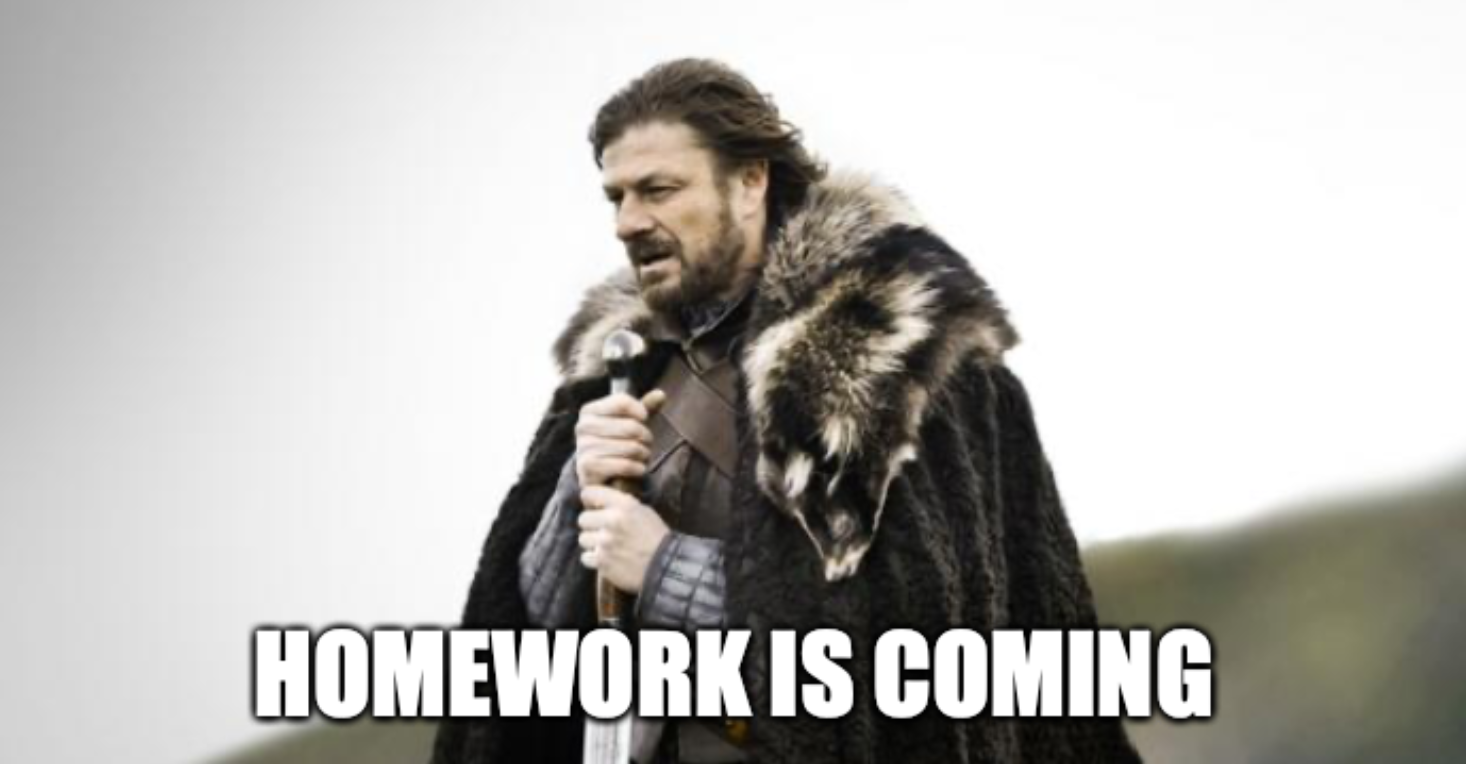


# Instructions for the homework
  > Follow the instructions in the notebook carefully
  


## General instructions
  * Do NOT remove ANYTHING that is already in the notebook.
  * Before you start, show the line number for the code cells:
    * Go to Tools -> Settings -> Editor -> show line numbers
  * Having **EXACTLY TWO** students per group is **MANDATORY**
  * The software must be commented.
  * The notebook will be converted to a PDF, so you must use prints and plots that are displayed in the derived PDF.
  * About this notebook:
    * Create a personal copy to be able to modify it: File > Save a copy in Drive
    * Rename the copied notebook `DMT2024-HW1.ipynb`


## Instructions for **code**:
  * DO NOT add code cells
  * DO NOT remove any code cells
  * Only edit the code cells containing the comment `#YOUR CODE STARTS HERE#`. Within those cells:
    * DO NOT remove ANYTHING that we have written (otherwise specified). In particular, the line `#REMOVE_OUTPUT#` is used in some cells to remove the output of those cells when the notebook is converted to PDF.
    * Add your code between line `#YOUR CODE STARTS HERE#` and line `#YOUR CODE ENDS HERE#`; **DO NOT REMOVE THESE COMMENTS**
    * The last line in each code cell is #THIS IS LINE \<TOT>#, where \<TOT> is a line number. The notebook is constructed so that \<TOT> matches with the line number in which it is written, but it may of course move as you add your code. **Make sure that, when you deliver it, that comment returns to line \<TOT>.** DO NOT CHANGE THE \<TOT> VALUE. Of course, this means that you have a limited number of lines of code that you may NOT exceed under any circumstances. On the other hand, if your code is shorter than that, you have to reach that line number with empty lines.

> Ensure that the notebook can be faithfully reproduced by anyone (hint: pseudo random number generation).

> If you need to set a random seed, set it to `1224`.

[comment]: <> (#REMOVE_CELL#)


## Instructions for **text**:
* DO NOT add text cells
* DO NOT remove text cells
* DO NOT modify the text cells we have created.
* Only edit text cells starting with the comment ------------YOUR TEXT STARTS HERE------------. Within those cells:
  * Do NOT remove anything we have entered.
  * **Add your own text after the line ------------YOUR TEXT STARTS HERE------------; DO NOT REMOVE THIS TEXT**
  * For each cell, a specific delivery will be given. If you are given a maximum number of sentences to write, both the dot "." and the semicolon ";" will be considered sentence dividers.

[comment]: <> (#REMOVE_CELL#)


## *Evaluation*

The homework will be evaluated based on the following criteria:

1. **Code Quality**: correctness, readability (length, comments, unnecessary repetitions)
2. **Quality of Textual Responses**: correctness, clarity, etc.
3. **Quality of Produced Visualizations** (tables/figures/etc.): correctness, clarity, etc.
4. **Quality**, **quantity** and **diversity** of experiments conducted, **results** achieved, etc. \[if applicable; will be clearly indicated\]
5. **Timely Submission**: late submissions will result in significant point deductions
6. **Plagiarism**: copying code/text from colleagues or online sources will result in significant point deductions \[it will be clearly indicated if borrowing code from other sources is allowed\]

[comment]: <> (#REMOVE_CELL#)

## Group composition:

Write down the list of group members. The format should be Last Name, First Name, Student ID. Group members should be sorted alphabetically by surname and placed on different lines.
Example:

Becchetti, Luca, 123456

Siciliano, Federico, 987654

------------YOUR TEXT STARTS HERE------------

Pannacci, Lorenzo, 1948926

Tromboni, Gabriele, 2088799

<div style="page-break-after: always; visibility: hidden">
\pagebreak
</div>

## Homework 1
The homework consists of three parts:

1. Vector Search

2. Near-Duplicates Detection

3. Dimensionality Reduction

# Part 1
In this part of the homework, you will explore vector search techniques.

Import **ALL** the Python packages that you need for Part 1.

In [ ]:
#REMOVE_OUTPUT#
!pip install --upgrade --no-cache-dir gdown
#YOUR CODE STARTS HERE#
!apt install libomp-dev
!pip install faiss-cpu
import faiss
import tarfile
import numpy as np
import os
import time
import matplotlib.pyplot as plt
import pandas as pd
import random
#YOUR CODE ENDS HERE#
#THIS IS LINE 15#

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  libomp-14-dev libomp5-14
Suggested packages:
  libomp-14-doc
The following NEW packages will be installed:
  libomp-14-dev libomp-dev libomp5-14
0 upgraded, 3 newly installed, 0 to remove and 45 not upgraded.
Need to get 738 kB of archives.
After this operation, 8,991 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy-updates/universe amd64 libomp5-14 amd64 1:14.0.0-1ubuntu1.1 [389 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy-updates/universe amd64 libomp-14-dev amd64 1:14.0.0-1ubuntu1.1 [347 kB]
Get:3 http://archive.ubuntu.com/ubuntu jammy/universe amd64 libomp-dev amd64 1:14.0-55~exp2 [3,074 B]
Fetched 738 kB in 0s (6,039 kB/s)
Selecting previously unselected package libomp5-14:amd64.
(Reading database ... 121918 files and directories currently installed.)
Preparing to unpack .../libomp5-14_1%3a

## Part 1.1
Your task involves evaluating various indexes based on three key metrics: the **quality** of retrieved results, **memory** consumption, and **time** efficiency.

This part must run within a maximum of **30** minutes. To meet this constraint, approximations can be made (using fewer documents, fewer queries) to *estimate* the required parameters. However, these approximations **must be explicitly indicated** in the code.

The **objectives** are:
1. Find the best option for each of the 3 metrics
2. Find an index that represents a good compromise between the 3 metrics

### 1.1.1
Download the Sift10K dataset.

In [ ]:
#YOUR CODE STARTS HERE#

!wget ftp://ftp.irisa.fr/local/texmex/corpus/siftsmall.tar.gz -q





#YOUR CODE ENDS HERE#
#THIS IS LINE 10#

### 1.1.2
If you need to, prepare here helper functions to run your computations.

In [ ]:
#YOUR CODE STARTS HERE#

def unzip_file(file_name: str):
  tar = tarfile.open(file_name, "r:gz")
  tar.extractall()

def ivecs_read(file_name: str):
    a = np.fromfile(file_name, dtype='int32')
    d = a[0]
    return a.reshape(-1, d + 1)[:, 1:].copy()

def fvecs_read(file_name: str):
    return ivecs_read(file_name).view('float32')

def memory_consumption(index):
  faiss.write_index(index, './temp.index')
  file_size = os.path.getsize('./temp.index')
  os.remove('./temp.index')
  return file_size / 1048576

def recall(index_retrieve, groundtruth, k: int):
  recalls = []
  for query in range(index_retrieve.shape[0]):
    recalls.append(np.mean([1 if i in groundtruth[query][:k] else 0 for i in index_retrieve[query]]))
  return round(np.mean(recalls), 4)

def get_search_time(index, queries, k):
  time = %timeit -n 1000 -o -q index.search(queries, k)
  time_interval = (round(time.average*1000, 3), round(time.stdev*1000, 3))
  return time_interval

random.seed(1224)






#YOUR CODE ENDS HERE#
#THIS IS LINE 40#

### 1.1.3
Initiate time calculation for Part 1.

In [ ]:
#YOUR CODE STARTS HERE#

timestamp_part1_start = time.perf_counter()





#YOUR CODE ENDS HERE#
#THIS IS LINE 10#

### 1.1.4
Prepare the data for vector search.


In [ ]:
#YOUR CODE STARTS HERE#

unzip_file('siftsmall.tar.gz')
x_base = fvecs_read('./siftsmall/siftsmall_base.fvecs')
x_query = fvecs_read('./siftsmall/siftsmall_query.fvecs')
ground_truth = ivecs_read('./siftsmall/siftsmall_groundtruth.ivecs')












#YOUR CODE ENDS HERE#
#THIS IS LINE 20#

Print the size of your variables.

[comment]: <> (#SHOW_CELL#)

In [ ]:
#YOUR CODE STARTS HERE#

print("Base shape: {}".format(x_base.shape))
print("Query shape: {}".format(x_query.shape))
print("Ground truth shape: {}".format(ground_truth.shape))



#YOUR CODE ENDS HERE#
#THIS IS LINE 10#

Base shape: (10000, 128)
Query shape: (100, 128)
Ground truth shape: (100, 100)


<div style="page-break-after: always; visibility: hidden">
\pagebreak
</div>

### 1.1.5
Prepare your baseline index and get its metrics.


In [ ]:
#YOUR CODE STARTS HERE#

# baseline index is IndexFlatL2 because is an 'exact' search index
d = 128
k = 100  # number of nearest neighbors to return

flat_index = faiss.IndexFlatL2(d)
flat_index.add(x_base)
D_flat, I_flat = flat_index.search(x_query, k)
memory_flat = memory_consumption(flat_index)
flat_recall = recall(I_flat, ground_truth, k)
flat_time = get_search_time(flat_index, x_query, k)






#YOUR CODE ENDS HERE#
#THIS IS LINE 20#

Why did you choose this index as baseline? Explain your answer in **at most 1 sentence**.

[comment]: <> (#SHOW_CELL#)

------------YOUR TEXT STARTS HERE------------

We choose a flat index as baseline because it is the simplest approach to the problem as it performs a straightforward exhaustive search between vectors and also produces the most accurate results, making it a good starting point to compare trade-offs between performances and other factors as memory used and search time.

<div style="page-break-after: always; visibility: hidden">
\pagebreak
</div>

### 1.1.6
Build and test as many indices as possible. For each of them, get the required metrics.

In [ ]:
#YOUR CODE STARTS HERE#

# Hierarchical Navigable Small World Index
M = 16  # number of connections each vertex will have
HNSW_index = faiss.IndexHNSWFlat(d, M)
HNSW_index.hnsw.efConstruction = 16 # depth of layers explored during index construction
HNSW_index.hnsw.efSearch = 64 # depth of layers explored during search
HNSW_index.add(x_base)
D_HNSW, I_HNSW = HNSW_index.search(x_query, k)
memory_HNSW = memory_consumption(HNSW_index)
HNSW_recall = recall(I_HNSW, I_flat, k)
HNSW_time = get_search_time(HNSW_index, x_query, k)

# Inverted File Index
nlist = 256  # number of cells/clusters to partition data into (the higher nlist the marginally larger memory usage but the lower search-time)
quantizer = faiss.IndexFlatIP(d)  # how the vectors will be stored/compared
IVF_index = faiss.IndexIVFFlat(quantizer, d, nlist)
IVF_index.train(x_base)  # we must train the index to cluster into cells
IVF_index.add(x_base)
IVF_index.nprobe = 16  # set how many of nearest cells to search ( increasing it prioritize search-quality )
D_ivf, I_ivf = IVF_index.search(x_query, k)
memory_IVF = memory_consumption(IVF_index)
IVF_recall = recall(I_ivf, I_flat, k)
IVF_time = get_search_time(IVF_index, x_query, k)

# LSH Index
nbits = d*8  # ‘resolution’ of the hashed vectors. A higher value means greater accuracy at the cost of more memory and slower search speeds.
LSH_index = faiss.IndexLSH(d, nbits)
LSH_index.add(x_base)
D_lsh, I_lsh = LSH_index.search(x_query, k)
memory_LSH = memory_consumption(LSH_index)
LSH_recall = recall(I_lsh, I_flat, k)
LSH_time = get_search_time(LSH_index, x_query, k)

# IVFPQ Index
nlist = 256  # how many Voronoi cells (must be >= k* which is 2**nbits)
nbits = 8  # when using IVF+PQ, higher nbits values are not supported
IVFPQ_index = faiss.IndexIVFPQ(faiss.IndexFlatL2(d), x_base.shape[1], nlist, 16, nbits)
IVFPQ_index.train(x_base)
IVFPQ_index.add(x_base)
IVFPQ_index.nprobe = 16
D_ivfpq, I_ivfpq = IVFPQ_index.search(x_query, k)
memory_IVFPQ = memory_consumption(IVFPQ_index)
IVFPQ_recall = recall(I_ivfpq, I_flat, k)
IVFPQ_time = get_search_time(IVFPQ_index, x_query, k)



#YOUR CODE ENDS HERE#
#THIS IS LINE 50#

### 1.1.7
Stop time calculation for Part 1.

In [ ]:
#YOUR CODE STARTS HERE#

timestamp_part1_stop = time.perf_counter()





#YOUR CODE ENDS HERE#
#THIS IS LINE 10#

Print the time.

[comment]: <> (#SHOW_CELL#)

In [ ]:
#YOUR CODE STARTS HERE#

time_elapsed_1 = timestamp_part1_stop - timestamp_part1_start

print("The execution lasted for {} seconds.".format(round(time_elapsed_1, 5)))



#YOUR CODE ENDS HERE#
#THIS IS LINE 10#

The execution lasted for 472.19643 seconds.


<div style="page-break-after: always; visibility: hidden">
\pagebreak
</div>

### 1.1.8
Produce a table with your results. If you have approximated your results, you need to write it explicitly and **possibly** do something to show this (e.g. standard deviation? confidence intervals?).

In [ ]:
#YOUR CODE STARTS HERE#

indexes = ['FlatL2', 'HNSWIndex', 'LSHIndex', 'IVFIndex', 'IVFPQIndex']
recalls = [flat_recall, HNSW_recall, LSH_recall, IVF_recall, IVFPQ_recall]
memories = [memory_flat, memory_HNSW, memory_LSH, memory_IVF, memory_IVFPQ]
times = [flat_time[0], HNSW_time[0], LSH_time[0], IVF_time[0], IVFPQ_time[0]]
stdevs = [flat_time[1], HNSW_time[1], LSH_time[1], IVF_time[1], IVFPQ_time[1]]

data = {
    'Recall': recalls,
    'Memory (MB)': memories,
    'Time average (ms)': times,
    'Time stdev (ms)': stdevs
}

df = pd.DataFrame(data, index=indexes)

df










#YOUR CODE ENDS HERE#
#THIS IS LINE 30#

,Recall,Memory (MB),Time average (ms),Time stdev (ms)
FlatL2,1.0000,4.882855,20.712,11.986
HNSWIndex,0.9515,6.256525,8.635,1.572
LSHIndex,0.7612,1.720792,26.616,0.993
IVFIndex,0.9238,5.086192,5.166,0.925
IVFPQIndex,0.7785,0.481007,5.836,0.649


If focusing solely on one metric, which index would you select? Why do you think that specific index got the best result for that metric? Explain your answer in **at most 3 sentences (1 for each metric)**.

[comment]: <> (#SHOW_CELL#)

------------YOUR TEXT STARTS HERE------------

Of course the Flat index has perfect values of Recall and it would be the go-to choice, but considering the indexes that implement trade-offs we would choose HNSWIndex and this choice is to be expected since we decided set for this index parameters to increase search quality in spite of the memory increase.

If we choose Memory Usage as performance metric we pick IVFPQIndex because takes up as little memory as possible as we expected due to PQ mechanism itself that is a form of dimensionality reduction.

If we choose Search-Time as performance metric we pick the IVFIndex which is the fast one within search-speed with the smallest standard deviation value because we used a really high value of nlist means that we must compare our vector to more centroid vectors but after selecting the nearest centroid’s cells to search, there will be fewer vectors within each cell.

<div style="page-break-after: always; visibility: hidden">
\pagebreak
</div>

If considering all metrics, which index would you choose and why? Explain your answer in **at most 2 sentences**.

[comment]: <> (#SHOW_CELL#)

------------YOUR TEXT STARTS HERE------------

Considering all metrics and our case scenario we think the best choice is to pick FlatL2Index, so the baseline as the best vector search index that reaches an **exact Recall** value.

Although FlatL2Index requires a higher search-time and a bit higher value of memory usage and has a problem in a scaling scenario, in our specific case with a small amount of data of not high dimensionality these two metrics are irrilevant respect to the recall performance of each index, so overall it is the best one.

<div style="page-break-after: always; visibility: hidden">
\pagebreak
</div>

### 1.1.9
Visualize your results. If you have approximated your results, you need to write it explicitly and **possibly** do something to show this (e.g. standard deviation? confidence intervals?).

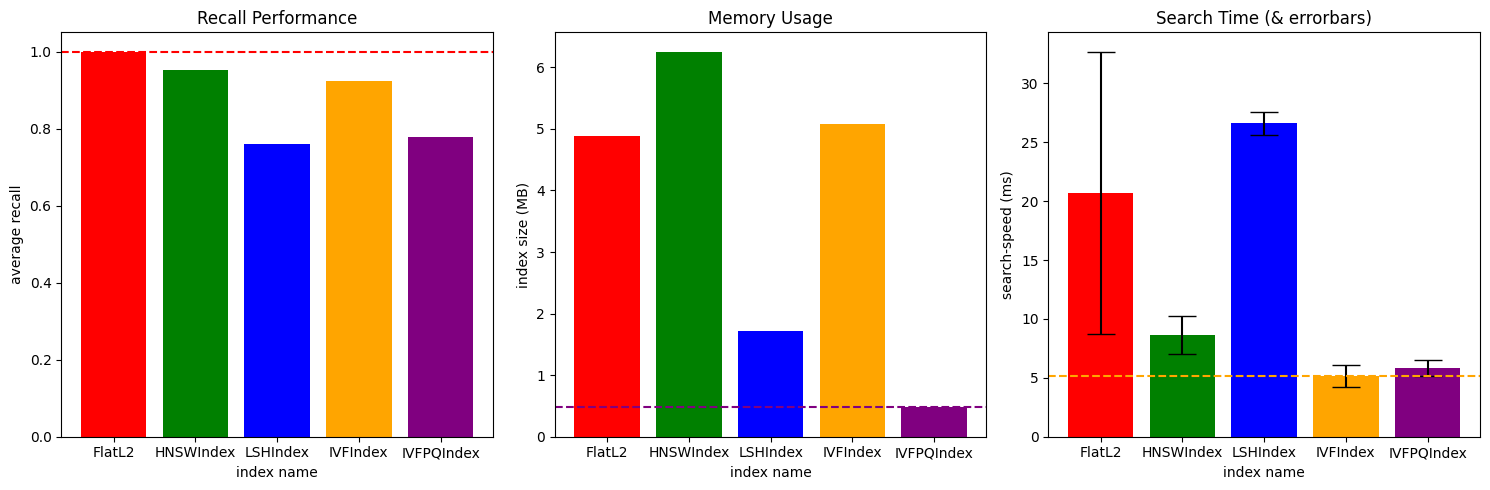

In [ ]:
#YOUR CODE STARTS HERE#

colors = ['red', 'green', 'blue', 'orange', 'purple']

fig, axs = plt.subplots(1, 3, figsize=(15, 5))
# plot Recall Performance
axs[0].bar(indexes, recalls, color = colors)
axs[0].set_xlabel('index name')
axs[0].set_ylabel('average recall')
axs[0].set_title('Recall Performance')
axs[0].axhline(y = max(recalls), color = colors[recalls.index(max(recalls))], linestyle = '--')

# plot Memory Usage
axs[1].bar(indexes, memories, color = colors)
axs[1].set_xlabel('index name')
axs[1].set_ylabel('index size (MB)')
axs[1].set_title('Memory Usage')
axs[1].axhline(y = min(memories), color = colors[memories.index(min(memories))], linestyle = '--')

# plot Search Times
axs[2].bar(indexes, times, color = colors, yerr = stdevs, align = 'center', ecolor = 'black', capsize = 10)
axs[2].set_xlabel('index name')
axs[2].set_ylabel('search-speed (ms)')
axs[2].set_title('Search Time (& errorbars)')
axs[2].axhline(y = min(times), color = colors[times.index(min(times))], linestyle = '--')

plt.tight_layout()
plt.show()




















#YOUR CODE ENDS HERE#
#THIS IS LINE 50#

Comment your results in **at most 3 sentences**, *possibly* providing new insights and with minimal overlap with previous answers.

[comment]: <> (#SHOW_CELL#)

------------YOUR TEXT STARTS HERE------------

As we can see from the plots each index has its drawbacks in some of the performance metrics we take into account.

HNSW and IVF indexes are very fast and precise providing a good recall value when compared to the baseline FlatL2, but they requires more memory usage and while we know from theory that HNSW will scale well in high-dimensionality scenarios this could lead to a scalability issues for IVF.

LSH and IVFPQ reach a similar lower recall performance but it is clear that IVFPQ is better than LSH under every aspect since IVFPQ has a slightly better recall despite using much less memory and computation time.

<div style="page-break-after: always; visibility: hidden">
\pagebreak
</div>

## Part 1.2

### 1.2.1
Suppose you have a document collection represented by an $NxM$ matrix. Vector search is to be performed on this matrix.
Our goal is to retain **all** the information while implementing a form of dimensionality reduction.

What options are available? What are the pros and cons?

**Use at most 3 sentences.**

----------YOUR TEXT STARTS HERE----------

Since it is required to retain all informations the only possible approach to
perform some kind of dimensionality reduction is reducing the search scope, so we can do it either using quantization techniques such as Product Quantization or using an indexes such as IVF through clustering with Voronoi cells or HNSW through eliminating intermediate connections between each incremental layer.

Product quantization help reducing the memory usage and the search time by using symbolic representations of the vectors and mapping of those symbols to reproduction values (centroids of sub-vector clustering), effectively keeping the original dimensionality but with the drawback of lower recall rates.

HNSW is the best performing index to do vector search in an high dimensionality space while IVF has the drawback of the so called 'edge problem' that we can be mitigated increasing the **nprobe**, but that would increase the number of adjacent cells to be searched increasing the scope and reducing the computational speed.

<div style="page-break-after: always; visibility: hidden">
\pagebreak
</div>

# Part 2

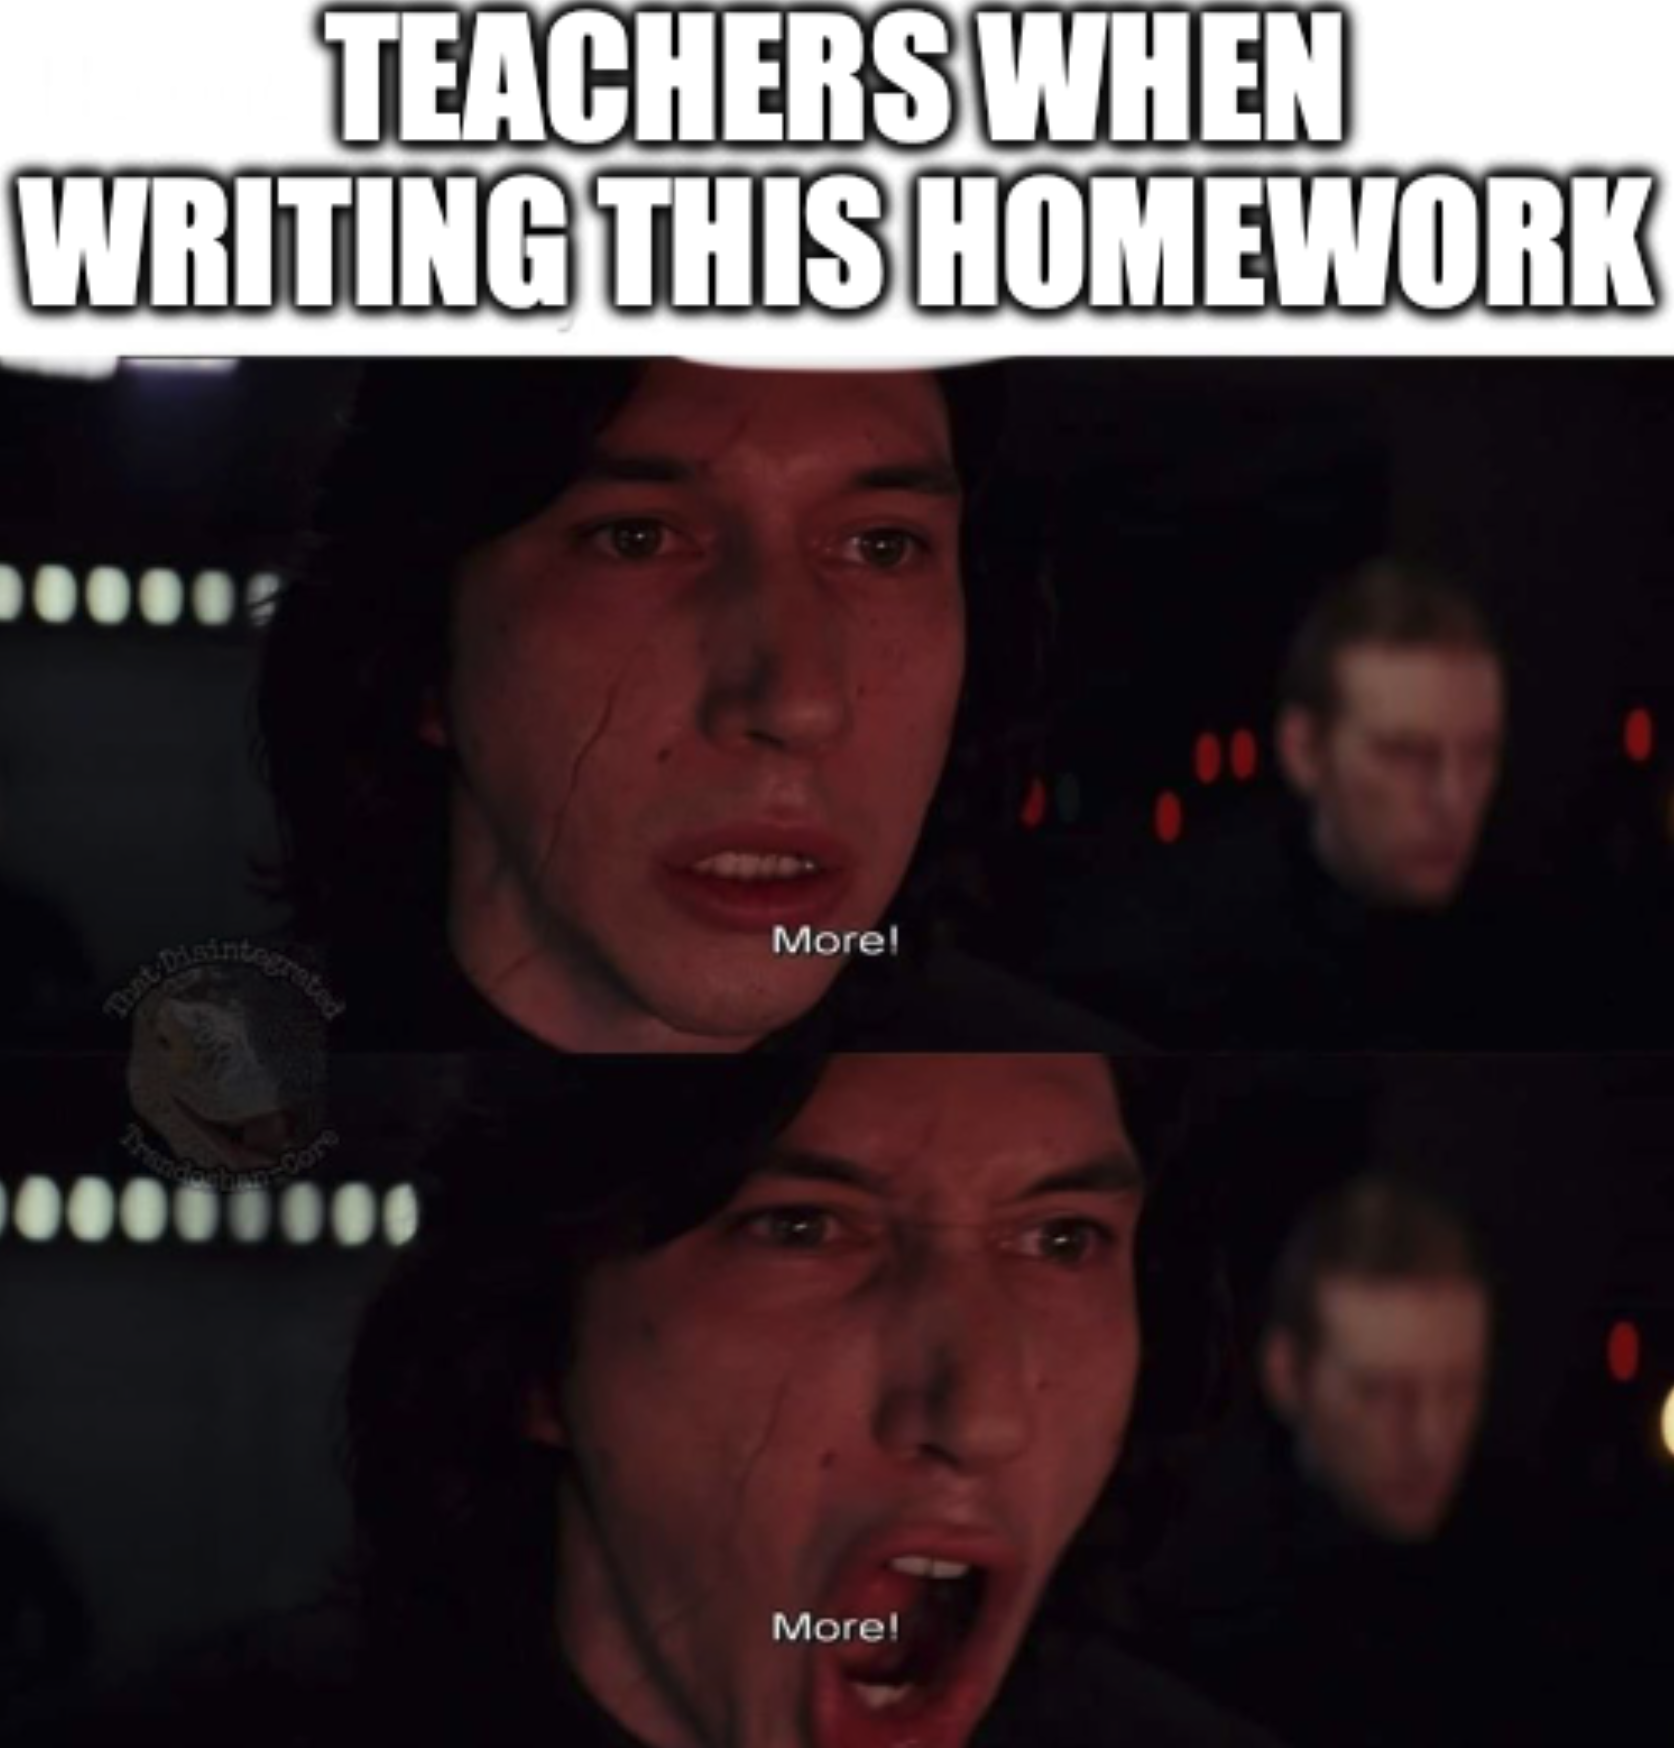

In this part of the homework, you have to find, in an approximated way, all near-duplicate documents inside a collection of documents.

These constraints **must** be satisfied while carrying out this part of the homework:

  * We will consider Near-duplicates all those pair of documents that have a Jaccard similarity greater than or equal to 0.88
  * Each set of shingles, that represents an original document, must be sketched in a Min-Hashing sketch with a length of at most 251
  * The probability to have as a near-duplicate candidate a pair of documents with Jaccard=0.88 must be > 0.99
  * The generation process of near-duplicate pairs you implement must generate the smallest amount of both **False-Negatives** and **False-Positives**
  * The running time of **all** the LSH process (LSH + approximate Jaccard) must be less than 4 minutes.

Import **ALL** the Python packages that you need for Part 2.

In [ ]:
#REMOVE_OUTPUT#
#YOUR CODE STARTS HERE#

import csv
import random
import itertools as it
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time



#YOUR CODE ENDS HERE#
#THIS IS LINE 15#


#### NDD functions
A range of functions to perform the Near-Duplicates pipeline is provided by us. You are free to use the functions from Lab 1. If you choose to do so, **you must not modify** them under any circumstances and you can simply copy the corresponding cell cells below. You must also indicate this in the next text cell (delete the other answer). If you decide to re-implement them, you may obtain better results (time, performance), but they must be properly commented.

------------YOUR TEXT STARTS HERE------------

I have chosen to use the functions from Lab 1: ***yes***

<div style="page-break-after: always; visibility: hidden">
\pagebreak
</div>


##### Shingling

In [ ]:
#IF YOU DECIDE TO RE-IMPLEMENT THIS FUNCTION, COMPLETE THIS CELL. OTHERWISE, DELETE IT.#
#YOUR CODE STARTS HERE#

def cleaner(text, set__characters_of_interest):
    new_text = ""
    #
    previous_copied_character = "a"
    for c_character in text:
        #
        c_character = c_character.lower()
        #
        if c_character not in set__characters_of_interest:
            c_character = " "
        #
        if c_character == " " and c_character == previous_copied_character:
            continue
        #
        new_text += c_character
        #
        previous_copied_character = c_character
        #
    #
    new_text = new_text.strip()
    #
    return new_text

def get_shingle_id(shingle):
    global max_shingle_id
    global map__shingle__shingle_id
    #
    shingle_id = map__shingle__shingle_id.get(shingle, -1)
    #
    if shingle_id >= 0:
        return shingle_id
    #
    max_shingle_id += 1
    shingle_id = max_shingle_id
    map__shingle__shingle_id[shingle] = max_shingle_id
    #
    return shingle_id

def shingler(text, width=2):
    #
    set__shingle_id = set()
    #
    tokenized_text = text.split(" ")
    #
    max_index_plus_1 = 1 if len(tokenized_text) <= width else len(tokenized_text) - width +1
    for index in range(max_index_plus_1):
        #
        c_shingle = tuple(tokenized_text[index:index + width])
        #
        shingle_id = get_shingle_id(c_shingle)
        #
        # if shingle_id in set__shingle_id:
        #    print(shingle_id, c_shingle)
        #
        res = set__shingle_id.add(shingle_id)
        #
    return set__shingle_id

def create_sets_of_shingle_ids(input_file_name, output_file_name,
                               input_file_delimiter='\t', input_file_quotechar='"',
                               set__characters_of_interest=[" "], shingle_width=3,
                               doc_id_column_idx=0, field_column_idx=1):

  output_file = open(output_file_name, 'w', encoding="utf-8")
  output_file_csv_writer = csv.writer(output_file, delimiter='\t', quotechar='"', quoting=csv.QUOTE_NONE)
  header = ['set_id', 'set_of_integers']
  output_file_csv_writer.writerow(header)
  #
  input_file = open(input_file_name, 'r', encoding="utf-8")
  input_file_csv_reader = csv.reader(input_file, delimiter=input_file_delimiter, quotechar=input_file_quotechar)
  next(input_file_csv_reader)
  for record in input_file_csv_reader:
      #
      doc_id = int(record[doc_id_column_idx])
      document = record[field_column_idx]
      #
      cleaned_document = cleaner(document, set__characters_of_interest)
      #
      set__shingle_id = shingler(cleaned_document, width=shingle_width)
      #
      output_file_csv_writer.writerow([doc_id, set__shingle_id])
      #
      #
      if doc_id % 1000 == 0:
          print("Last processed doc_id:", doc_id)
      #
  input_file.close()
  output_file.close()
  print("Last processed doc_id:", doc_id)
  print()
  print("max_shingle_id=", max_shingle_id)
  print()
  print()
  return max_shingle_id

#YOUR CODE ENDS HERE#
#THIS IS LINE 100#

<div style="page-break-after: always; visibility: hidden">
\pagebreak
</div>


##### MinWise Hashing

In [ ]:
#IF YOU DECIDE TO RE-IMPLEMENT THIS FUNCTION, COMPLETE THIS CELL. OTHERWISE, DELETE IT.#
#YOUR CODE STARTS HERE#

def is_prime(number):
    #
    if number == 2:
        return True
    if (number % 2) == 0:
        return False
    for j in range(3, int(number ** 0.5 + 1), 2):
        if (number % j) == 0:
            return False
    #
    return True

def create_hash_functions(number_of_hash_functions, upper_bound_on_number_of_distinct_elements, seed=42):
    random.seed(seed)
    #
    map__hash_function_id__a_b_p = {}
    #
    set_of_all_hash_functions = set()
    while len(set_of_all_hash_functions) < number_of_hash_functions:
        a = random.randint(1, upper_bound_on_number_of_distinct_elements - 1)
        b = random.randint(0, upper_bound_on_number_of_distinct_elements - 1)
        p = random.randint(upper_bound_on_number_of_distinct_elements, 10 * upper_bound_on_number_of_distinct_elements)
        while is_prime(p) == False:
            p = random.randint(upper_bound_on_number_of_distinct_elements,
                               10 * upper_bound_on_number_of_distinct_elements)
        #
        c_hash_function = (a, b, p)
        set_of_all_hash_functions.add(c_hash_function)
    #
    for c_hash_function_id, c_hash_function in enumerate(set_of_all_hash_functions):
        map__hash_function_id__a_b_p[c_hash_function_id] = c_hash_function
    #
    return map__hash_function_id__a_b_p

def create_c_set_MinWiseHashing_sketch(c_set,
                                       map_as_list__index__a_b_p,
                                       total_number_of_hash_functions, use_numpy_version = True):
    if use_numpy_version:
      app = np.array(map_as_list__index__a_b_p)
      c_set_MinWiseHashing_sketch = list(np.min((app[:,:1]*np.array(list(c_set))[None,:]+app[:,1:2])%app[:,2:],axis=1))
    else:
      plus_inf = float("+inf")
      c_set_MinWiseHashing_sketch = [plus_inf] * total_number_of_hash_functions
      for c_element_id in c_set:
          for index, (a, b, p) in enumerate(map_as_list__index__a_b_p):
              c_hash_value = (a * c_element_id + b) % p
              if c_hash_value < c_set_MinWiseHashing_sketch[index]:
                  c_set_MinWiseHashing_sketch[index] = c_hash_value
    return c_set_MinWiseHashing_sketch

def create_MinWiseHashing_sketches(input_file_name, upper_bound_on_number_of_distinct_elements,
                                   number_of_hash_functions_that_is_also_the_sketch_lenght_and_also_the_number_of_simulated_permutations,
                                   output_file_name, use_numpy_version=True):
    #
    map__hash_function_id__a_b_p = create_hash_functions(
        number_of_hash_functions_that_is_also_the_sketch_lenght_and_also_the_number_of_simulated_permutations,
        upper_bound_on_number_of_distinct_elements)
    #
    map__set_id__MinWiseHashing_sketch = {}
    #
    total_number_of_hash_functions = len(map__hash_function_id__a_b_p)
    # sorted_list_all_hash_function_id = sorted(map__hash_function_id__a_b_p.keys())
    map_as_list__index__a_b_p = tuple([(a, b, p) for a, b, p in map__hash_function_id__a_b_p.values()])
    #
    input_file = open(input_file_name, 'r', encoding="utf-8")
    input_file_csv_reader = csv.reader(input_file, delimiter='\t', quotechar='"', quoting=csv.QUOTE_NONE)
    header = next(input_file_csv_reader)
    num_record_so_far = 0
    for record in input_file_csv_reader:
      num_record_so_far += 1
      if num_record_so_far % 100 == 0:
          print(num_record_so_far)
      c_set_id = int(record[0])
      c_set = eval(record[1])

      c_set_MinWiseHashing_sketch = create_c_set_MinWiseHashing_sketch(c_set,map_as_list__index__a_b_p,
                                                                       total_number_of_hash_functions,
                                                                       use_numpy_version)

      #print(len(c_set_MinWiseHashing_sketch))
      map__set_id__MinWiseHashing_sketch[c_set_id] = c_set_MinWiseHashing_sketch
    input_file.close()
    #
    output_file = open(output_file_name, 'w', encoding="utf-8")
    output_file_csv_writer = csv.writer(output_file, delimiter='\t', quotechar='"', quoting=csv.QUOTE_NONE)
    header = ['set_id', 'MinWiseHashing_sketch']
    output_file_csv_writer.writerow(header)
    sorted_list_all_set_id = sorted(map__set_id__MinWiseHashing_sketch.keys())
    for c_set_id in sorted_list_all_set_id:
        output_file_csv_writer.writerow([c_set_id, str(map__set_id__MinWiseHashing_sketch[c_set_id])])
    output_file.close()
    #
    return


#YOUR CODE ENDS HERE#
#THIS IS LINE 100#

<div style="page-break-after: always; visibility: hidden">
\pagebreak
</div>


##### Locality-Sensitive Hashing

In [ ]:
#IF YOU DECIDE TO RE-IMPLEMENT THIS FUNCTION, COMPLETE THIS CELL. OTHERWISE, DELETE IT.#
#YOUR CODE STARTS HERE#

def load_map__set_id__MinWiseHashing_sketch_from_file(input_file_name):
    map__set_id__MinWiseHashing_sketch = {}
    #
    input_file = open(input_file_name, 'r', encoding="utf-8")
    input_file_csv_reader = csv.reader(input_file, delimiter='\t', quotechar='"', quoting=csv.QUOTE_NONE)
    header = next(input_file_csv_reader)
    for record in input_file_csv_reader:
        c_set_id = int(record[0])
        c_MinhiseHashing_sketch = tuple(eval(record[1]))
        #
        map__set_id__MinWiseHashing_sketch[c_set_id] = c_MinhiseHashing_sketch
        #
    input_file.close()
    #
    return map__set_id__MinWiseHashing_sketch

def get_set_of_CANDIDATES_to_be_near_duplicates(r, b, map__set_id__MinWiseHashing_sketch):
    #
    set_of_CANDIDATES_to_be_near_duplicates = set()
    #
    for c_band_progressive_id in range(b):
        #
        print("c_band_progressive_id", c_band_progressive_id)
        #
        c_band_starting_index = c_band_progressive_id * r
        c_band_ending_index = (c_band_progressive_id + 1) * r
        #
        map__band__set_set_id = {}
        #
        for c_set_id in map__set_id__MinWiseHashing_sketch:
            #
            if r * b != len(map__set_id__MinWiseHashing_sketch[c_set_id]):
                n = len(map__set_id__MinWiseHashing_sketch[c_set_id])
                message = "ERROR!!! n != r*b " + str(n) + "!=" + str(r * b) + "; " + str(n) + "!=" + str(r) + "*" + str(
                    b)
                raise ValueError(message)
            #
            c_band_for_c_set = tuple(
                map__set_id__MinWiseHashing_sketch[c_set_id][c_band_starting_index:c_band_ending_index])
            #
            if c_band_for_c_set not in map__band__set_set_id:
                map__band__set_set_id[c_band_for_c_set] = set()
            map__band__set_set_id[c_band_for_c_set].add(c_set_id)
            #

        for c_set_set_id in map__band__set_set_id.values():
            #
            if len(c_set_set_id) > 1:
                #
                for set_id_a, set_id_A in it.combinations(c_set_set_id, 2):
                    if set_id_a < set_id_A:
                        set_of_CANDIDATES_to_be_near_duplicates.add((set_id_a, set_id_A))
                    else:
                        set_of_CANDIDATES_to_be_near_duplicates.add((set_id_A, set_id_a))
        #
    #
    return set_of_CANDIDATES_to_be_near_duplicates

def compute_approximate_jaccard(set_a_MinWiseHashing_sketch, set_b_MinWiseHashing_sketch):
    appx_jaccard = 0.
    #
    for index in range(len(set_a_MinWiseHashing_sketch)):
        #
        if set_a_MinWiseHashing_sketch[index] == set_b_MinWiseHashing_sketch[index]:
            appx_jaccard += 1
        #
    appx_jaccard /= len(set_a_MinWiseHashing_sketch)
    #
    return appx_jaccard

def compute_approximate_jaccard_to_REDUCE_the_number_of_CANDIDATES_to_be_near_duplicates(
        set_of_CANDIDATES_to_be_near_duplicates,
        map__set_id__MinWiseHashing_sketch, jaccard_threshold):
    map__set_a_id__set_A_id__appx_jaccard = {}
    #
    for set_a_id, set_A_id in set_of_CANDIDATES_to_be_near_duplicates:
        #
        set_a_MinWiseHashing_sketch = map__set_id__MinWiseHashing_sketch[set_a_id]
        set_A_MinWiseHashing_sketch = map__set_id__MinWiseHashing_sketch[set_A_id]
        #
        appx_jaccard = compute_approximate_jaccard(set_a_MinWiseHashing_sketch, set_A_MinWiseHashing_sketch)
        #
        if appx_jaccard >= jaccard_threshold:
            map__set_a_id__set_A_id__appx_jaccard[(set_a_id, set_A_id)] = appx_jaccard
        #
    #
    return map__set_a_id__set_A_id__appx_jaccard

def mine_couples_of_Near_Duplicates(input_file_name, output_file_name, r, b, jaccard_threshold):
    #
    print("Starting the loading of the MinWiseHashing sketches from the input file.")
    map__set_id__MinWiseHashing_sketch = load_map__set_id__MinWiseHashing_sketch_from_file(input_file_name)
    print()
    print("Number of sets=", len(map__set_id__MinWiseHashing_sketch))
    print()
    #
    print("Starting the mining of the CANDIDATES couples to be near duplicates.")
    set_of_CANDIDATES_to_be_near_duplicates = get_set_of_CANDIDATES_to_be_near_duplicates(r, b,
                                                                                          map__set_id__MinWiseHashing_sketch)
    #
    print()
    print("Number of pairs of sets to be near-duplicate CANDIDATES=", len(set_of_CANDIDATES_to_be_near_duplicates))
    print()
    #
    map__set_a_id__set_A_id__appx_jaccard = compute_approximate_jaccard_to_REDUCE_the_number_of_CANDIDATES_to_be_near_duplicates(
        set_of_CANDIDATES_to_be_near_duplicates, map__set_id__MinWiseHashing_sketch, jaccard_threshold)
    print()
    print("Number of REFINED pairs of sets to be near-duplicate CANDIDATES=",
          len(map__set_a_id__set_A_id__appx_jaccard))
    print()
    #
    output_file = open(output_file_name, 'w', encoding="utf-8")
    output_file_csv_writer = csv.writer(output_file, delimiter='\t', quotechar='"', quoting=csv.QUOTE_NONE)
    header = ['set_a_id', 'set_b_id', 'approximate_jaccard']
    output_file_csv_writer.writerow(header)
    sorted_list_all_set_id = sorted(map__set_id__MinWiseHashing_sketch.keys())
    for set_a_id__set_A_id in map__set_a_id__set_A_id__appx_jaccard:
        appx_jaccard = map__set_a_id__set_A_id__appx_jaccard[set_a_id__set_A_id]
        output_file_csv_writer.writerow([set_a_id__set_A_id[0], set_a_id__set_A_id[1], appx_jaccard])
    output_file.close()
    return

#YOUR CODE ENDS HERE#
#THIS IS LINE 100#

<div style="page-break-after: always; visibility: hidden">
\pagebreak
</div>

## Part 2.1

### 2.1.1
Download the dataset from the Drive link (code already provided).

In [ ]:
#REMOVE_OUTPUT#
!gdown 16LQDmla82XFK1B0lr8H9ycm01pxjURXN

Downloading...
From (original): https://drive.google.com/uc?id=16LQDmla82XFK1B0lr8H9ycm01pxjURXN
From (redirected): https://drive.google.com/uc?id=16LQDmla82XFK1B0lr8H9ycm01pxjURXN&confirm=t&uuid=a5af9bee-3516-4ec4-bd2b-cf2b73a2da5d
To: /content/150K_lyrics_from_MetroLyrics.csv
100% 186M/186M [00:03<00:00, 48.0MB/s]


### 2.1.2
Inspect the dataset: print the list of fields names. Print the value of the `year` field for the first 4 documents.

In [ ]:
#YOUR CODE STARTS HERE#

# load dataset
df = pd.read_csv('/content/150K_lyrics_from_MetroLyrics.csv')

print("Field names:")

# print every column name
for field in list(df.columns):
    print("- '{}'".format(field))

print("\nValue of the 'Year' field for the first 4 documents:")

# print year of 4 first documents
for i in range(0, 4):
    print("{}. year: {}".format(i + 1, df["year"][i]))


#YOUR CODE ENDS HERE#
#THIS IS LINE 20#

Field names:
- 'ID'
- 'song'
- 'year'
- 'artist'
- 'genre'
- 'lyrics'

Value of the 'Year' field for the first 4 documents:
1. year: 2009
2. year: 2009
3. year: 2009
4. year: 2009


### 2.1.3
Turn the lyrics field of each document into a sets of shingles of length 3 and save the result to a file named `hw1__set_id_set_of_integers.tsv`

In [ ]:
#REMOVE_OUTPUT#
#YOUR CODE STARTS HERE#

# set up global variables
max_shingle_id = -1
map__shingle__shingle_id = {}

characters = set([' ', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l',        # create list of characters to use; since we are working on lyrics
                  'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z'])  # we believe numbers are not useful and have been removed

create_sets_of_shingle_ids(input_file_name = '/content/150K_lyrics_from_MetroLyrics.csv',
                           output_file_name = '/content/hw1__set_id_set_of_integers.tsv',
                           input_file_delimiter = ',',                                    # input is a .csv so ',' is the delimiter
                           input_file_quotechar = '"',
                           set__characters_of_interest = characters,
                           shingle_width = 3,                                             # shingle length is set to 3 as requested
                           doc_id_column_idx = 0,                                         # 'ID' field in the dataset is in position 0
                           field_column_idx = 5)                                          # 'lyrics' field in the dataset is in position 5
#YOUR CODE ENDS HERE#
#THIS IS LINE 20#

Last processed doc_id: 0
Last processed doc_id: 1000
Last processed doc_id: 2000
Last processed doc_id: 4000
Last processed doc_id: 5000
Last processed doc_id: 7000
Last processed doc_id: 9000
Last processed doc_id: 13000
Last processed doc_id: 14000
Last processed doc_id: 16000
Last processed doc_id: 17000
Last processed doc_id: 18000
Last processed doc_id: 19000
Last processed doc_id: 22000
Last processed doc_id: 25000
Last processed doc_id: 26000
Last processed doc_id: 27000
Last processed doc_id: 29000
Last processed doc_id: 31000
Last processed doc_id: 33000
Last processed doc_id: 34000
Last processed doc_id: 36000
Last processed doc_id: 37000
Last processed doc_id: 38000
Last processed doc_id: 40000
Last processed doc_id: 42000
Last processed doc_id: 43000
Last processed doc_id: 44000
Last processed doc_id: 46000
Last processed doc_id: 47000
Last processed doc_id: 48000
Last processed doc_id: 49000
Last processed doc_id: 50000
Last processed doc_id: 52000
Last processed doc_id: 5

11571503

### 2.1.4
Load the file containing the sets of shingles and apply MinWiseHashing, saving the result into a file named `hw1__set_id_MinWiseHashing_sketch.tsv`. Choose the number of hash functions (n) in relation to the constraints highlighted at the beginning of part 2.

In [ ]:
#REMOVE_OUTPUT#
#YOUR CODE STARTS HERE#

n = 240

create_MinWiseHashing_sketches(input_file_name = '/content/hw1__set_id_set_of_integers.tsv',
                               upper_bound_on_number_of_distinct_elements = max_shingle_id,
                               number_of_hash_functions_that_is_also_the_sketch_lenght_and_also_the_number_of_simulated_permutations = n,
                               output_file_name = "/content/hw1__set_id_MinWiseHashing_sketch.tsv")









#YOUR CODE ENDS HERE#
#THIS IS LINE 20#

100
200
300
400
500
600
700
800
900
1000
1100
1200
1300
1400
1500
1600
1700
1800
1900
2000
2100
2200
2300
2400
2500
2600
2700
2800
2900
3000
3100
3200
3300
3400
3500
3600
3700
3800
3900
4000
4100
4200
4300
4400
4500
4600
4700
4800
4900
5000
5100
5200
5300
5400
5500
5600
5700
5800
5900
6000
6100
6200
6300
6400
6500
6600
6700
6800
6900
7000
7100
7200
7300
7400
7500
7600
7700
7800
7900
8000
8100
8200
8300
8400
8500
8600
8700
8800
8900
9000
9100
9200
9300
9400
9500
9600
9700
9800
9900
10000
10100
10200
10300
10400
10500
10600
10700
10800
10900
11000
11100
11200
11300
11400
11500
11600
11700
11800
11900
12000
12100
12200
12300
12400
12500
12600
12700
12800
12900
13000
13100
13200
13300
13400
13500
13600
13700
13800
13900
14000
14100
14200
14300
14400
14500
14600
14700
14800
14900
15000
15100
15200
15300
15400
15500
15600
15700
15800
15900
16000
16100
16200
16300
16400
16500
16600
16700
16800
16900
17000
17100
17200
17300
17400
17500
17600
17700
17800
17900
18000
18100
18200
18300
18400
1850

Provide an explanation for your choice of *n* in **exactly one sentence**.

[comment]: <> (#SHOW_CELL#)

------------YOUR TEXT STARTS HERE------------

We choose $n = 240$ because its prime factor decomposition is $2 \times 2 \times 2 \times 2 \times 3 \times 5$ and this grant us a good compromise between the variety on the factors and a reasonable high number of couples of $r$ and $b$ that satisfies the percentage of the truly similar documents that we find for $jac=0.88$ to be $>0.99$.

<div style="page-break-after: always; visibility: hidden">
\pagebreak
</div>

### 2.1.5
To perform Locality Sensivity Hashing, you have to choose the number of rows (r) and the number bands (b). List all the possible choices of r and b that satisfy the constraints highlighted at the beginning of part 2, according to the number of hash functions you chose.

For all of these configurations, plot all the associated S-curves. The S-curve is defined as the probability (y-axis) that a pair of documents with Jaccard similarity j (x-axis) is selected as a near-duplicate candidate given r and b. Plot all S-curves in the same plot.

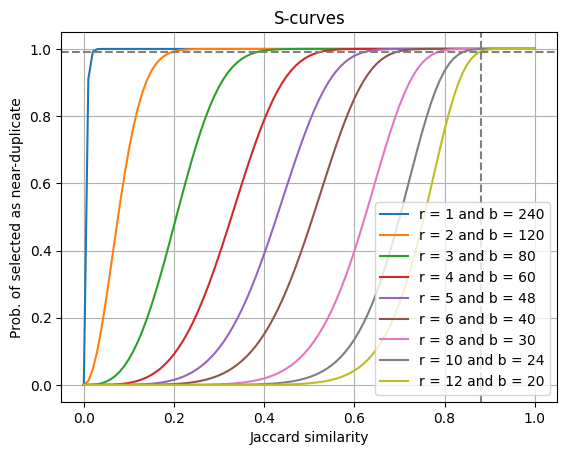

In [ ]:
#YOUR CODE STARTS HERE#
couples = []
for i in range(1, n + 1): # find all possible couples of b and r for the fixed n
    if n % i == 0:
        couples.append((i, n // i))

def s_curve_formula(r, b, jac = 0.88):
    return 1 - (1 - jac**r)**b

x = np.arange(0, 1.01, 0.01)
for r, b in couples:
    if s_curve_formula(r, b) > 0.99: # check if satisfy constraints
        y = s_curve_formula(r, b, x)
        plt.plot(x, y, label = 'r = {} and b = {}'.format(r, b)) # plot S-curves

# create lines to visualize constraint
plt.axvline(x = 0.88, color = 'gray', linestyle = '--')
plt.axhline(y = 0.99, color = 'gray', linestyle = '--')

# create rest of plot
plt.xlabel('Jaccard similarity')
plt.ylabel('Prob. of selected as near-duplicate')
plt.title('S-curves')

plt.grid(True)
plt.legend()
plt.show()

#YOUR CODE ENDS HERE#
#THIS IS LINE 30#

### 2.1.6
Among all the configurations you plotted in the previous step, choose the one that gives the smallest amount of False-Positives and False-Negatives near-duplicates candidates, satisfying the provided constraints. You **must** take into account, that after the LSH procedure, the approximate Jaccard similarity between near-duplicate candidates is computed and used to reduce their number.

Load the file containing the MinWiseHashing sketches and perform Locality Sensivity Hashing, using the parameters you chose. Save the Near-Duplicates candidates obtained to a file named `hw1__NearDuplicates_set_a_id_set_b_id_approximate_jaccard.tsv`.

If you are still within the time constraints, you have the option to execute additional LSH procedures.

Compute the execution time of each LSH procedure.

In [ ]:
#YOUR CODE STARTS HERE#

selected_r, selected_b = 3, 80  # the best values between those showed in the plot
                                # by the reasons provided in the answer below

jaccard_threshold = 0.88        # as said at the start of this section "We will consider
                                # Near-duplicates all those pair of documents that have
                                # a Jaccard similarity greater than or equal to 0.88

# start timing
timestamp_part2_start = time.perf_counter()

# LSH pipeline execution
mine_couples_of_Near_Duplicates(input_file_name = "/content/hw1__set_id_MinWiseHashing_sketch.tsv",
                                output_file_name = "/content/hw1__NearDuplicates_set_a_id_set_b_id_approximate_jaccard.tsv",
                                r = selected_r,
                                b = selected_b,
                                jaccard_threshold = jaccard_threshold)

# stop timing
timestamp_part2_stop = time.perf_counter()



























#YOUR CODE ENDS HERE#
#THIS IS LINE 50#

Starting the loading of the MinWiseHashing sketches from the input file.

Number of sets= 150000

Starting the mining of the CANDIDATES couples to be near duplicates.
c_band_progressive_id 0
c_band_progressive_id 1
c_band_progressive_id 2
c_band_progressive_id 3
c_band_progressive_id 4
c_band_progressive_id 5
c_band_progressive_id 6
c_band_progressive_id 7
c_band_progressive_id 8
c_band_progressive_id 9
c_band_progressive_id 10
c_band_progressive_id 11
c_band_progressive_id 12
c_band_progressive_id 13
c_band_progressive_id 14
c_band_progressive_id 15
c_band_progressive_id 16
c_band_progressive_id 17
c_band_progressive_id 18
c_band_progressive_id 19
c_band_progressive_id 20
c_band_progressive_id 21
c_band_progressive_id 22
c_band_progressive_id 23
c_band_progressive_id 24
c_band_progressive_id 25
c_band_progressive_id 26
c_band_progressive_id 27
c_band_progressive_id 28
c_band_progressive_id 29
c_band_progressive_id 30
c_band_progressive_id 31
c_band_progressive_id 32
c_band_progressive

Print the execution time of each LSH and the complete exection time.

[comment]: <> (#SHOW_CELL#)

In [ ]:
#YOUR CODE STARTS HERE#

part_2_computation_time = timestamp_part2_stop - timestamp_part2_start

print("The computation time of the full LSH process is {} seconds.".format(part_2_computation_time))



#YOUR CODE ENDS HERE#
#THIS IS LINE 10#

The computation time of the full LSH process is 124.50928517100056 seconds.


Provide an explanation for your method and which final result you are retaining in **at most 4 sentences**.

[comment]: <> (#SHOW_CELL#)

------------YOUR TEXT STARTS HERE------------

To choose the parameters $r$ and $b$ we must consider the objective to minimize both false positives and false negatives while remaining inside the time constraint of 4 minutes for the full LSH process (LSH + approximate Jaccard), however in a real-world scenarios we would have started with a fast curve with reasonable performances and computed increasingly more demanding curves that yielded better and better results until the constraint of time was met.

The false positives that we introduce with the LSH are later recovered (regardless of their amount) during the approximate Jaccard computation since this operation computes the real Jaccard distance between signatures.

Meanwhile the false negatives introduced by LSH are not recoverable later, therefore we must choose the parameters that give us the minimum amount of them (the leftmost S-curve) while also considering the constraint on computation time as the more the curve is on the left the higher the amount of false positives that leads to higher computation times.

We have decided to use the couple $r = 3$ and $b = 80$ since it has a computation time of around 2 minutes while the alternative curve further to the left had a computation time beyond the constraint ($\sim$ 5 minutes).


<div style="page-break-after: always; visibility: hidden">
\pagebreak
</div>

### 2.1.7
Load the file containing the number of near-duplicates candidates. Print the number of near-duplicates candidates you found.

In [ ]:
#YOUR CODE STARTS HERE#

df = pd.read_csv('/content/hw1__NearDuplicates_set_a_id_set_b_id_approximate_jaccard.tsv', delimiter = '\t')

n_near_duplicates_candidates = df.shape[0]

print("The number of near-duplicates candidates that has been found is: {}".format(n_near_duplicates_candidates))





















#YOUR CODE ENDS HERE#
#THIS IS LINE 30#

The number of near-duplicates candidates that has been found is: 19481


<div style="page-break-after: always; visibility: hidden">
\pagebreak
</div>

## Part 2.2
You will be given a scenario and you will have to provide the best solution.

### 2.2.1

Let us consider the same scenario as in Part 2.1, with the only addition of not wanting more than 100 False Positives. How would the choice of the LSH configuration change? Would you need any more information to satisfy the new constraint? Would you need to modify the Near-Duplicates Detection pipeline? A brute-force approach is not considered as a valid solution.

Provide your answer in **at most 3 sentences**.

------------YOUR TEXT STARTS HERE------------

The question ask us to give guarantees for the false positives to be below a certain fixed amount, however every possible approach that involve the use of Min-Hashing Sketches can give us only probabilistic results, meaning that with the current pipeline we can’t satisfy the new constraint.

An approach we can think of to solve this issue is to add to the pipeline an ulterior step that computes the real Jaccard similarity between items, but since this operation has a very high computation time to make it feasible inside the time constraint we would be forced to be more conservative on the selection of near-duplicate candidates, meaning that we should move the S-curve much more to the right.

A more extreme approach that would however avoid the computation of the real Jaccard similarity is to always propose no more than 100 near-duplicate candidates (E.g. top 100 highest approximate Jaccard similarities), this would lead the number of false negatives to be high but would satisfy the new constraint and can easily fit inside the time constraint.

<div style="page-break-after: always; visibility: hidden">
\pagebreak
</div>

# Part 3
In this part of the homework, you have to deal with Dimensionality Reduction.

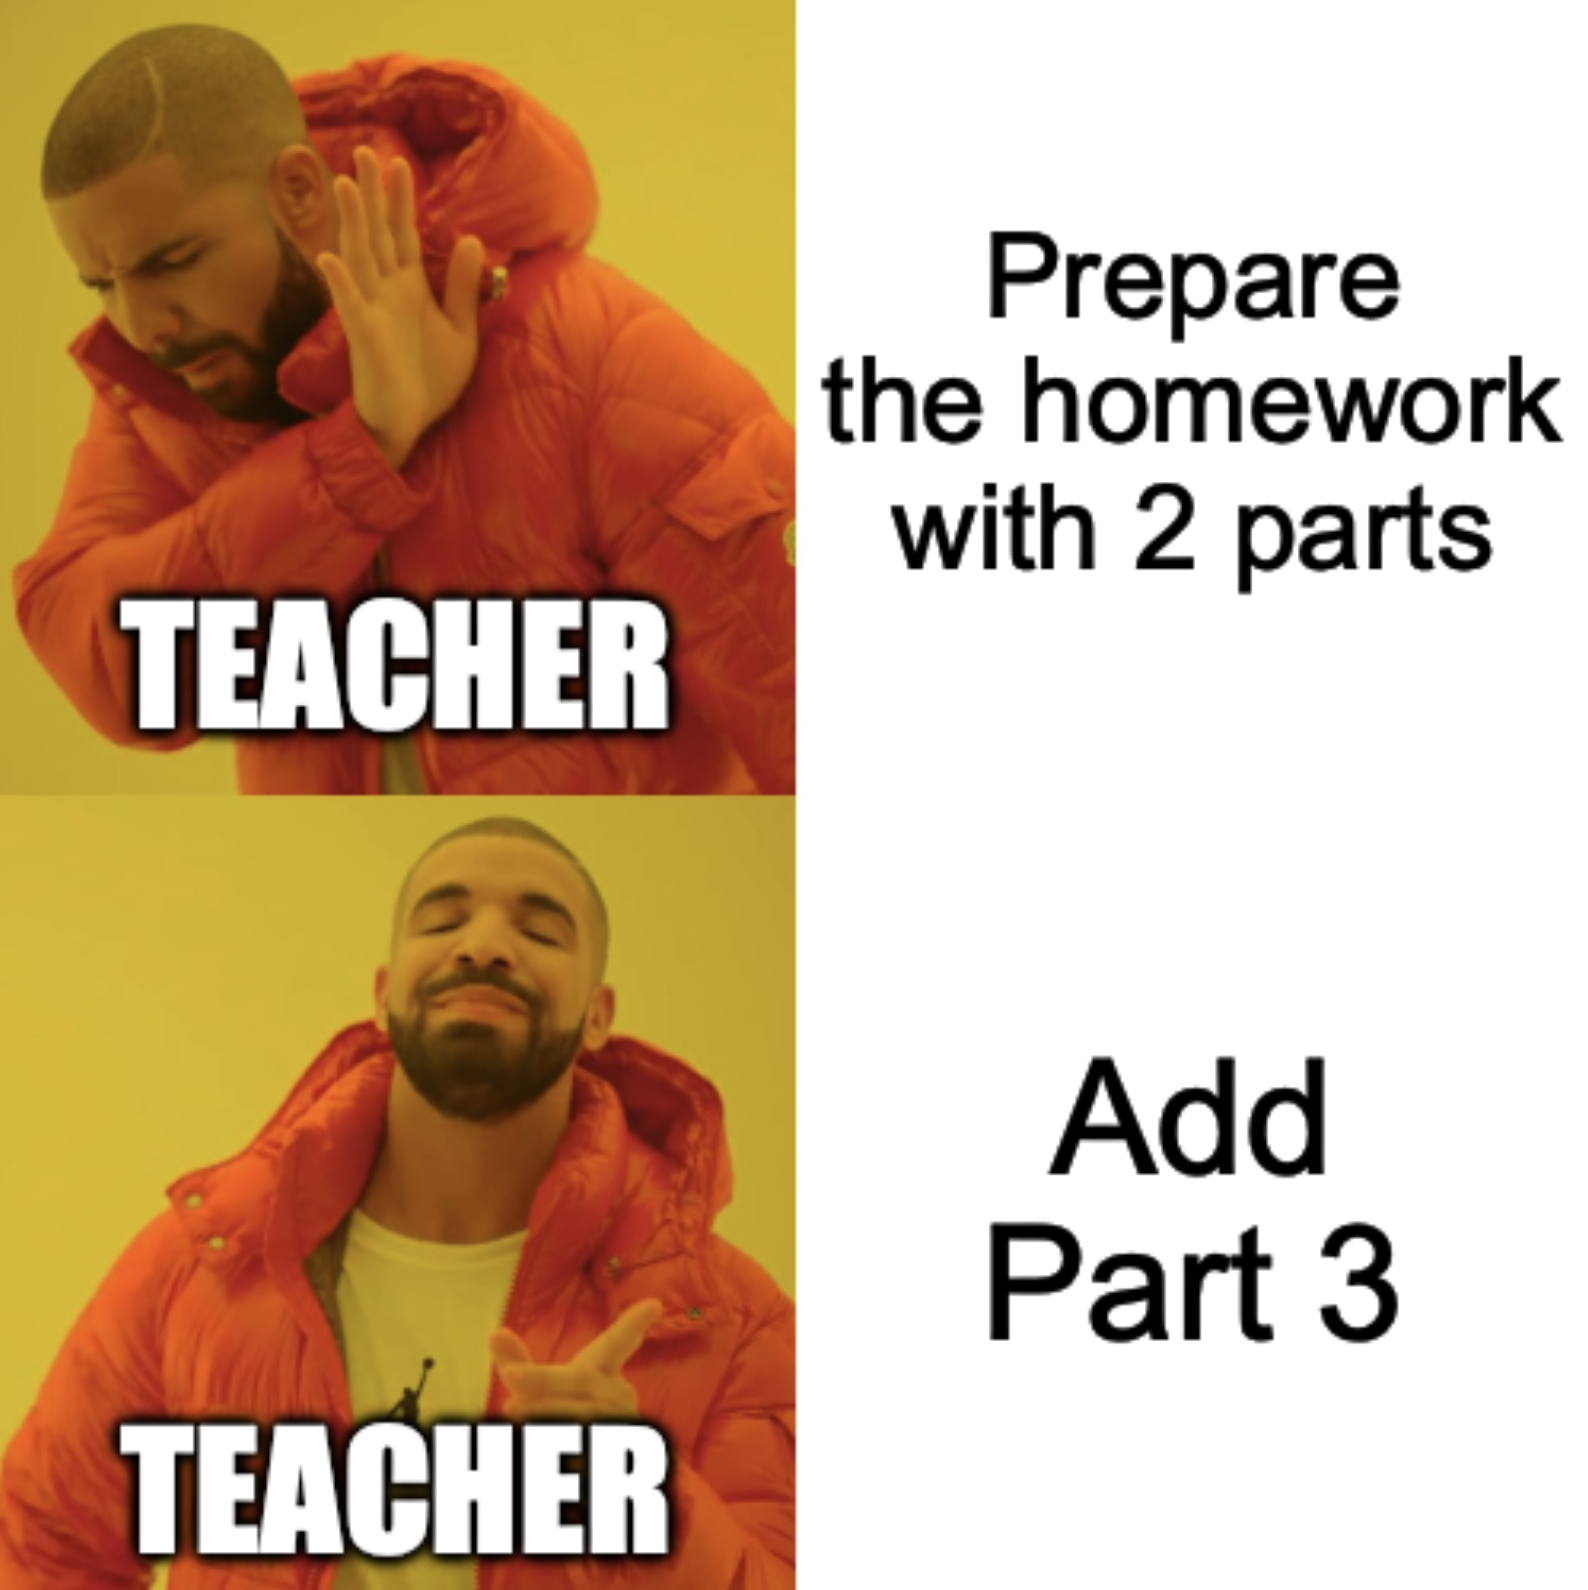

Import **ALL** the Python packages that you need for Part 3.

In [ ]:
#REMOVE_OUTPUT#
#YOUR CODE STARTS HERE#

import time
import random
import numpy as np
import pandas as pd
import nltk
nltk.download('stopwords')
from nltk.tokenize import RegexpTokenizer
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
from gensim import corpora
from gensim.models import LsiModel
from gensim.models.coherencemodel import CoherenceModel
import scipy.sparse
import matplotlib.pyplot as plt

#YOUR CODE ENDS HERE#
#THIS IS LINE 20#

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## Part 3.1
The data you need to process consists of reviews.

You have to carry out Topic Modeling.

The goal is to achieve a topic division within the following limits:

- The total computation may not exceed 20 minutes
- The division into topics must be the "best one"

### 3.1.1
Download the data from the Drive link (code already provided).

In [ ]:
#REMOVE_OUTPUT#
!gdown 1fAivTG_Uj6P_3D7QM8_VrADB243Rdq5T

Downloading...
From: https://drive.google.com/uc?id=1fAivTG_Uj6P_3D7QM8_VrADB243Rdq5T
To: /content/text.csv
100% 36.8M/36.8M [00:00<00:00, 61.9MB/s]


### 3.1.2
Initiate time calculation for Part 3.

In [ ]:
#YOUR CODE STARTS HERE#

timestamp_part3_start = time.perf_counter()





#YOUR CODE ENDS HERE#
#THIS IS LINE 10#

### 3.1.3
Preprocess the data

> Each document must be a list of terms

> Discard documents that have less than 12 (non-unique) words before the preprocessing (split by whitespace, ignore punctuation)

> After preprocessing, each document must be represented by at least 6 tokens

- Several preprocessing options are possible



In [ ]:
#YOUR CODE STARTS HERE#

df = pd.read_csv("/content/text.csv", names = ["text"])

# discard documents that have less than 12 (non-unique) words before the
# preprocessing (split by whitespace, ignore punctuation)
df["n_words"] = df["text"].apply(lambda x: len(x.split(" ")))
df = df[df['n_words'] >= 12]

# preprocessing

# substitute uppercase with lowercase
df.loc[:, "text"] = df["text"].apply(lambda x: x.lower())

# remove punctuation and numbers
df.loc[:, "text"] = df["text"].str.replace(r'(\\n)|[^a-z ]', ' ', regex=True)

# split into terms
df["preprocessed_terms"] = df["text"].apply(lambda x: x.split(" "))

# remove stopwords
en_stop = set(stopwords.words('english'))
df.loc[:, "preprocessed_terms"] = df["preprocessed_terms"].apply(lambda x: [term for term in x if term not in en_stop])

# remove small words (less then 2 letters)
df.loc[:, "preprocessed_terms"] = df["preprocessed_terms"].apply(lambda x: [term for term in x if len(term) >= 2])

# after preprocessing, each document must be represented by at least 6 tokens
df = df[df['preprocessed_terms'].apply(lambda x: len(x) >= 6)]

# stemming

# we have decided to use a stemmer from various tests it seems that the use of
# a lemmatizer or a stemmer does not influence the top 3 topic that are selected

p_stemmer = PorterStemmer()
df["stemmed_terms"] = df["preprocessed_terms"].apply(lambda x: [p_stemmer.stem(term) for term in x])

#YOUR CODE ENDS HERE#
#THIS IS LINE 40#

Print at most 6 documents where the (preprocessed) term `eating` appears.

[comment]: <> (#SHOW_CELL#)

In [ ]:
#YOUR CODE STARTS HERE#

term = "eating"
# get all documents that contains the (non-stemmed) term 'eating'
df_eating = df[df['preprocessed_terms'].apply(lambda x: term in x)]
# print the first 6 documents (= list of stemmed terms) of the previous subset
print(df_eating.head(n = 6)["stemmed_terms"])

#YOUR CODE ENDS HERE#
#THIS IS LINE 10#

4      [food, good, husband, ate, coupl, week, ago, f...
32     [know, bad, mcdonald, get, star, review, mean,...
45     [mean, person, vindict, person, bear, friendli...
72     [incred, experi, would, say, goe, one, memor, ...
86     [brick, wood, fire, smoker, cast, iron, door, ...
143    [alway, good, experi, eat, lunch, yea, bit, ru...
Name: stemmed_terms, dtype: object


<div style="page-break-after: always; visibility: hidden">
\pagebreak
</div>

### 3.1.4
Build a dictionary of the terms in the documents.

In [ ]:
#YOUR CODE STARTS HERE#

# create dictionary from collection of documents
dictionary = corpora.Dictionary(df["stemmed_terms"])

# we have decided to remove words that are too common, as example "food", "good" or "place"

# we have tested that if we keep those words all topic use them but if we don't
# use them the top 3 topics remain the same but they are expressed with
# different words making the logic behind the topic division more clear

dictionary.filter_extremes(no_above = 0.3)






#YOUR CODE ENDS HERE#
#THIS IS LINE 20#

Print out the 5 most common terms

[comment]: <> (#SHOW_CELL#)

In [ ]:
#YOUR CODE STARTS HERE#

term_frequencies = [(term, freq) for term, freq in dictionary.dfs.items()]      # get couples of terem and frequency
sorted_terms = sorted(term_frequencies, key=lambda x: x[1], reverse=True)       # order by frequency
for i in range(0, 5):                                                           # get and print top 5
    term, freq = sorted_terms[i]
    print("n.{} most common term is '{}' with a frequency of {}.".format(i + 1, dictionary[term], freq))

#YOUR CODE ENDS HERE#
#THIS IS LINE 10#

n.1 most common term is 'great' with a frequency of 13838.
n.2 most common term is 'would' with a frequency of 13075.
n.3 most common term is 'back' with a frequency of 12930.
n.4 most common term is 'order' with a frequency of 12083.
n.5 most common term is 'realli' with a frequency of 11416.


<div style="page-break-after: always; visibility: hidden">
\pagebreak
</div>

### 3.1.5
Perform a document-term encoding of the dataset.

- Several encodings are possible

In [ ]:
#YOUR CODE STARTS HERE#

doc_term_matrix = [dictionary.doc2bow(doc) for doc in df["stemmed_terms"]]















#YOUR CODE ENDS HERE#
#THIS IS LINE 20#

Print out the sparsity of the matrix

[comment]: <> (#SHOW_CELL#)

In [ ]:
#YOUR CODE STARTS HERE#
size_original_matrix = len(doc_term_matrix)*len(dictionary)
print("Document-Term Matrix has shape {} x {}. It is made of {} elements.".format(len(doc_term_matrix), len(dictionary), size_original_matrix))
size_sparse_matrix = sum(len(col) for col in doc_term_matrix)
print("\nOur sparse representation is instead made of {} elements.".format(sum(len(col) for col in doc_term_matrix)))
percentage_sparsity = (1 - size_sparse_matrix / size_original_matrix) * 100
print("\nThefore the matrix is {}% sparse!".format(percentage_sparsity))

#YOUR CODE ENDS HERE#
#THIS IS LINE 10#

Document-Term Matrix has shape 48905 x 13567. It is made of 663494135 elements.

Our sparse representation is instead made of 2459819 elements.

Thefore the matrix is 99.62926288715424% sparse!


<div style="page-break-after: always; visibility: hidden">
\pagebreak
</div>

### 3.1.6
Perform Latent Semantic Analysis for at least 3 different numbers of topics.

In [ ]:
#YOUR CODE STARTS HERE#

# set random seed
random.seed(1224)

# set number of topics to explore
n_topics_list = range(1, 10)

# populate list of models
lsa_models = []
for n_topics in n_topics_list:
    model = LsiModel(doc_term_matrix,
                    num_topics = n_topics,
                    id2word = dictionary,
                    random_seed = 1224)

    lsa_models.append(model)

#YOUR CODE ENDS HERE#
#THIS IS LINE 20#

### 3.1.7
For each of the calculations above, calculate a measure of the "goodness" of the division into topics.

In [ ]:
#YOUR CODE STARTS HERE#

# we use three difference coherence scores
coherence_scores_c_v = []
coherence_scores_c_uci = []
coherence_scores_c_npmi = []

for model in lsa_models:
    # coherence measure c_v
    coherence_scores_c_v.append(CoherenceModel(model = model, texts = df["stemmed_terms"], dictionary = dictionary, coherence = 'c_v').get_coherence())

    # coherence measure c_uci
    coherence_scores_c_uci.append(CoherenceModel(model = model, texts = df["stemmed_terms"], dictionary = dictionary, coherence = 'c_uci').get_coherence())

    # coherence measure c_npmi
    coherence_scores_c_npmi.append(CoherenceModel(model = model, texts = df["stemmed_terms"], dictionary = dictionary, coherence = 'c_npmi').get_coherence())


#YOUR CODE ENDS HERE#
#THIS IS LINE 20#

Plot the measure as the number of topics varies.

[comment]: <> (#SHOW_CELL#)

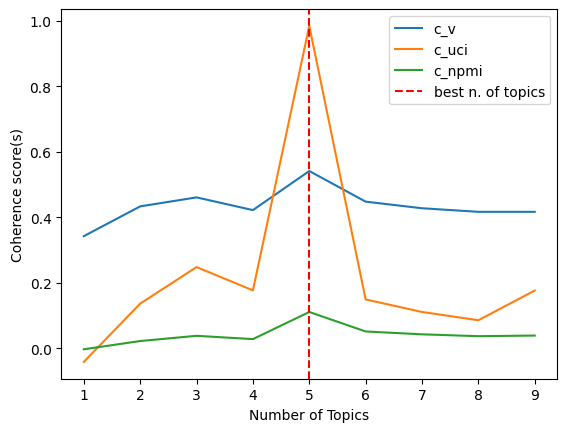

In [ ]:
#YOUR CODE STARTS HERE#

# plot coherence scores
plt.plot(n_topics_list, coherence_scores_c_v,  label = 'c_v')
plt.plot(n_topics_list, coherence_scores_c_uci, label = 'c_uci')
plt.plot(n_topics_list, coherence_scores_c_npmi, label = 'c_npmi')

# labels
plt.xlabel("Number of Topics")
plt.ylabel("Coherence score(s)")

# get and plot bet topics number
best_topic_number = coherence_scores_c_v.index(max(coherence_scores_c_v)) + 1
plt.axvline(x = best_topic_number, color = 'red', linestyle = '--', label = "best n. of topics")

plt.legend()
plt.show()

#YOUR CODE ENDS HERE#
#THIS IS LINE 20#

Which number of topics is the "best" to model this dataset?

**Use at most 2 sentences.**

[comment]: <> (#SHOW_CELL#)

----------YOUR TEXT STARTS HERE----------

We measured the coherence scores across number of topics ranging from 1 to 10 using three different kind of measures from the gensim library, namely 'c_v', 'c_uci' and 'c_npmi'. The three scores seem to have a consensus for 5 topics as the best amount.

<div style="page-break-after: always; visibility: hidden">
\pagebreak
</div>

### 3.1.8
Stop time calculation for Part 3.

In [ ]:
#YOUR CODE STARTS HERE#

timestamp_part3_stop = time.perf_counter()





#YOUR CODE ENDS HERE#
#THIS IS LINE 10#

Print the time.

[comment]: <> (#SHOW_CELL#)

In [ ]:
#YOUR CODE STARTS HERE#

time_elapsed = timestamp_part3_stop - timestamp_part3_start

print("The execution lasted for {} seconds.".format(time_elapsed))



#YOUR CODE ENDS HERE#
#THIS IS LINE 10#

The execution lasted for 1186.0123459019997 seconds.


<div style="page-break-after: always; visibility: hidden">
\pagebreak
</div>

### 3.1.9
Using LSA with the number of topics you identified as best, print the 8 most important words for the 3 most important topics.

In [ ]:
#YOUR CODE STARTS HERE#

best_model = lsa_models[best_topic_number - 1]

for topic_i, words_and_importance in best_model.print_topics(num_topics = 3, num_words = 8):
    print("TOPIC:", topic_i + 1)

    for app in words_and_importance.split(" + "):
        value,token = app.split("*")
        value = float(value)
        token = str(token.replace('"', ""))
        print("\t",value,token)

    print()




#YOUR CODE ENDS HERE#
#THIS IS LINE 20#

TOPIC: 1
	 0.226 order
	 0.195 would
	 0.161 back
	 0.154 us
	 0.145 realli
	 0.129 tri
	 0.128 great
	 0.127 even

TOPIC: 2
	 -0.405 order
	 0.374 room
	 0.197 hotel
	 0.168 stay
	 0.167 call
	 -0.148 chicken
	 -0.145 fri
	 -0.128 tast

TOPIC: 3
	 0.373 order
	 -0.266 great
	 0.258 us
	 -0.212 room
	 0.206 ask
	 0.197 wait
	 0.182 minut
	 -0.153 realli



Explain how you selected the 3 most important topics.

**Use at most 1 sentence.**

[comment]: <> (#SHOW_CELL#)

----------YOUR TEXT STARTS HERE----------

The criterion to select the most significant topics we used is the magnitude of the diagonal matrix $\Sigma$ of the decomposition, but since the SVD procedure already order them in this way we can just call the 'print_topics' method.


Try to give an explanation of the topic division you obtained.

**Use at most 2 sentences.**

[comment]: <> (#SHOW_CELL#)

----------YOUR TEXT STARTS HERE----------

We can try to understand the reasoning behind the topics on the base of the most meaningful words (= highest coefficient magnitude) and the sign of their coefficients.

The first topic has positive signs and contains words that seem to be about restaurants ('order', 'tr(y)') that leaved a such a good impression to make the reviewer return ("would", "back", "great"), the second topic has negative signs on words about restaurants ("order", "chicken", "tast(e)") but postive signs for words about accomodation ("room", "hotel", "stay") while the third topic has a negative signs on 'room' and 'great' and positive ones on 'order' and 'wait', making us believe it is about negative experiences on restaurants that have to do with long wait times and finally even if not in the top 3 topics it is worth to mention that one of the other topics managed to cluster together reviews written in a different language.


<div style="page-break-after: always; visibility: hidden">
\pagebreak
</div>

## Part 3.2

### 3.2.1
Suppose you have $K$ matrices $\{X_1,\dots,X_K\}$, each with a different $N_k$ number of samples and $M_k$ number of features.

Assume that each feature occupies a different number $b_k$, dependent on the matrix, of memory units and that this cannot be changed (e.g. you cannot change the precision of floats).

Suppose further that each matrix has the same "importance".

You only have $B$ units of memory available on your storage medium.

Assuming that the entire dataset cannot fit on your storage medium, how would you accommodate all $K$ matrices and all their $N_k$ samples while retaining as much information about your data as possible?

**Use at most 3 sentences.**

----------YOUR TEXT STARTS HERE----------

The approach we will use will be based on **dimensionality reduction** instead of **feature selection** since it trades off the interpretability of the output features with the maximum possible information retaining given the constraint on memory.

We can model the problem as the well-known optimization problem of the **Knapsack problem** where the constraint is an upper bound on the weight seen as the total memory occupied and instead of maximizing the value we minimize the amount of loss information (that can be measured from the magnitude of the eigenvalues for PCA or singular values for SVD), which can be alternatively seen as a maximization of the retained information.

Once we solve this optimization problem, which can be done for example using the **Branch and Bound** method, we get for each matrix which features we should be kept and which should be removed and we have just to apply those dimensionality reductions to each matrix.

<div style="page-break-after: always; visibility: hidden">
\pagebreak
</div>


# Submission instructions

Follow the instructions precisely
1. Run the whole notebook up to this point
  * Click on this text cell and go to Runtime > Run before
  * It is essential that the notebook can be run from start to finish without us having to change anything.
2. Download the current notebook
  * File -> Download -> Download .ipynb
3. Upload the downloaded notebook in the current runtime
  * In the left sidebar menu, open the last tab (Files)
  * Click on the first button under the File title (Page with arrow pointing up)
  * In the new window, upload the notebook just downloaded



4. To turn the notebook into a pdf you need to install a Tex extension. Simply run the next cell of code:

In [ ]:
#REMOVE_CELL#
!apt-get install texlive-xetex texlive-fonts-recommended texlive-plain-generic

5. Now, run the next cell to set some cell tags in the notebook file.

In [ ]:
#REMOVE_CELL#
import nbformat as nbf
from glob import glob
notebooks = glob("/content/**/*.ipynb", recursive=True)

text_search_dict = ["YOUR TEXT STARTS HERE","#YOUR CODE STARTS HERE#","#SHOW_CELL#"]

for ipath in notebooks:
    print(ipath)
    ntbk = nbf.read(ipath, nbf.NO_CONVERT)

    for cell in ntbk.cells:
        cell_type = cell['cell_type'] == "code"

        cell_tags = cell.get('metadata', {}).get('tags', [])
        cell_tags = set(cell_tags)
        if "remove_cell" in cell_tags:
            cell_tags.remove("remove_cell")

        if cell_type == 0: #markdown
          if (cell['source'][0]!="#" and text_search_dict[cell_type] not in cell['source'] and text_search_dict[-1] not in cell['source'] and "pagebreak" not in cell['source']) or "#REMOVE_CELL#" in cell['source']:
            cell_tags.add("remove_cell")

        else: #code
          #if text_search_dict[cell_type] not in cell['source'] or "#REMOVE_CELL#" in cell['source']:
          if "#REMOVE_CELL#" in cell['source']:
            cell_tags.add("remove_cell")
          elif "#REMOVE_OUTPUT#" in cell['source']:
            cell_tags.add("remove_output")

        if len(cell_tags) > 0:
            cell['metadata']['tags'] = list(cell_tags)

    nbf.write(ntbk, ipath)

/content/DMT2024_HW1.ipynb


6. Now, run the next cell to transform the notebook to PDF without the code cells.
  * The file will appear in the menu on the left (refresh if needed). The file should be named `DMT2024_HW1.pdf`
  * Rename this file **Surname1_Surname2_DMT2024_HW1_report.pdf** (e.g. Becchetti_Siciliano_DMT2024_HW1_report.pdf). Sort the surnames alphabetically.
  * Click on it and using the right button or the three dots at its side, click on download to transfer it to your local PC
  

In [ ]:
#REMOVE_CELL#
!jupyter nbconvert /content/DMT2024_HW1.ipynb --to pdf --TagRemovePreprocessor.remove_cell_tags='{"remove_cell"}' -TagRemovePreprocessor.remove_all_outputs_tags='{"remove_output"}'

[NbConvertApp] Converting notebook /content/DMT2024_HW1.ipynb to pdf
[NbConvertApp] Support files will be in DMT2024_HW1_files/
[NbConvertApp] Making directory ./DMT2024_HW1_files
[NbConvertApp] Making directory ./DMT2024_HW1_files
[NbConvertApp] Making directory ./DMT2024_HW1_files
[NbConvertApp] Writing 149636 bytes to notebook.tex
[NbConvertApp] Building PDF
[NbConvertApp] Running xelatex 3 times: ['xelatex', 'notebook.tex', '-quiet']
[NbConvertApp] Running bibtex 1 time: ['bibtex', 'notebook']
[NbConvertApp] WARNING | bibtex had problems, most likely because there were no citations
[NbConvertApp] PDF successfully created
[NbConvertApp] Writing 287717 bytes to /content/DMT2024_HW1.pdf


7. Now, rename the downloaded notebook **Surname1_Surname2_DMT2024_HW1_notebook.ipynb** (e.g. Becchetti_Siciliano_DMT2024_HW1_notebook.ipynb). Sort the surnames alphabetically.

8. Now that you have both files, you need to upload them to Classroom. Only the student with the surname that comes first in alphabetical order **must** upload the files. Only the files uploaded by this student will be graded. Upload the report (.pdf) first, then the notebook (.ipynb).